**segmentation on whole image**

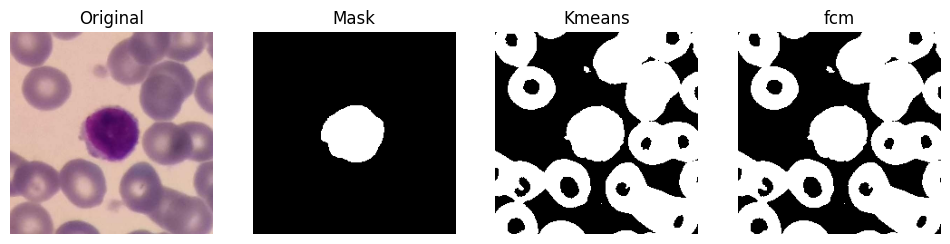

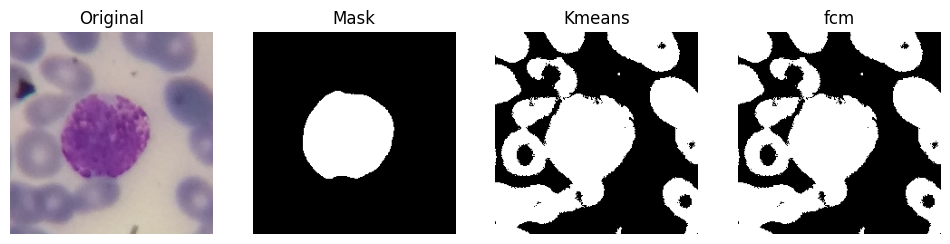

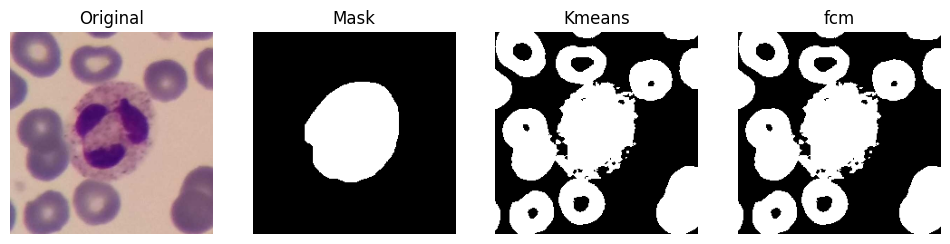

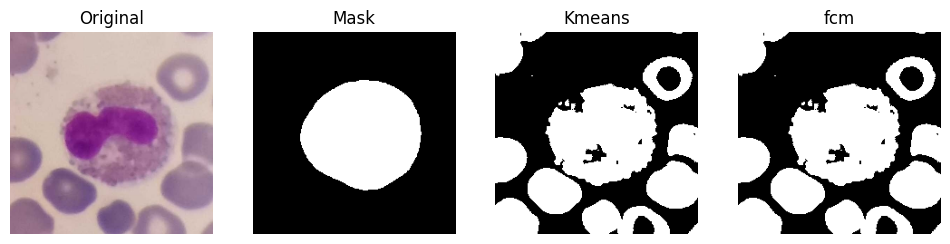

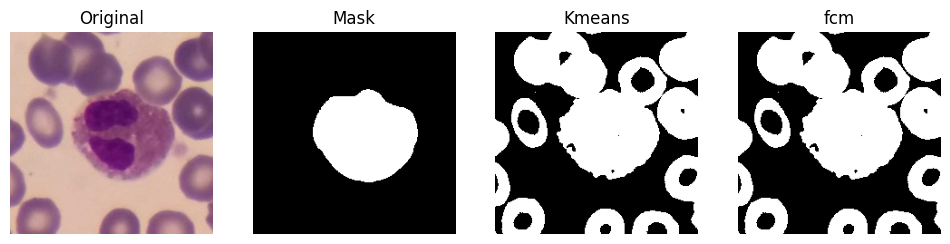

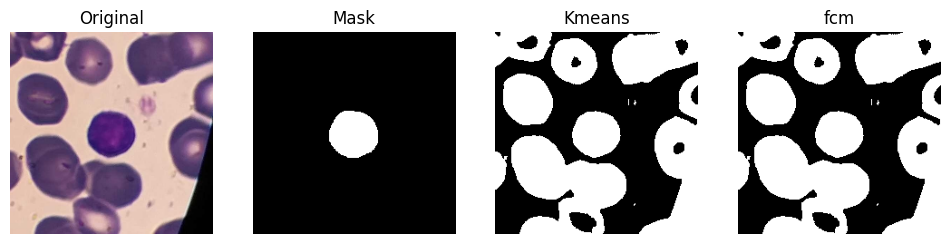

Mean Dice for K-means: 0.36746014588755543
Mean Dice for FCM    : 0.36734008481151403


In [34]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def dist(pixels, center):
    return np.abs(pixels - center)

def kmeans(img, iters=10):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    pixels = img_gray.flatten()

    c1 = pixels[np.random.randint(len(pixels))]
    c2 = pixels[np.random.randint(len(pixels))]

    for _ in range(iters):
        d1 = dist(pixels, c1)
        d2 = dist(pixels, c2)
        mask = d1 < d2
        c1_new = pixels[mask].mean()  if np.any(mask)  else c1
        c2_new = pixels[~mask].mean() if np.any(~mask) else c2
        if abs(c1_new - c1) < 1e-2 and abs(c2_new - c2) < 1e-2:
            break
        c1, c2 = c1_new, c2_new

    result = mask.reshape(img_gray.shape).astype(np.uint8) * 255
    if c1 > c2:
        result = 255 - result 
    return result

def fcm(img, iters=10, m=2):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    h, w = img_gray.shape
    u1 = np.random.rand(h, w)
    u2 = 1 - u1

    c1, c2 = 0, 0
    for _ in range(iters):
        c1 = np.sum((u1**m) * img_gray) / (np.sum(u1**m) + 1e-6)
        c2 = np.sum((u2**m) * img_gray) / (np.sum(u2**m) + 1e-6)
        d1 = np.abs(img_gray - c1) + 1e-6
        d2 = np.abs(img_gray - c2) + 1e-6
        u1 = 1 / (1 + (d1 / d2) ** (2 / (m - 1)))
        u2 = 1 - u1

    seg = (u1 > u2).astype(np.uint8) * 255
    if c1 > c2:
        seg = 255 - seg  # flip so darker cluster = white in output
    return seg

def dice(img1, img2):
    img1 = img1.flatten() > 0
    img2 = img2.flatten() > 0
    intersection = np.sum(img1 * img2)
    return 2.0 * intersection / (np.sum(img1) + np.sum(img2))

img_dir  = '/kaggle/input/datasets/ntxmaihd/raabin-wbc-segmentation/Train_bmp'
mask_dir = '/kaggle/input/datasets/ntxmaihd/raabin-wbc-segmentation/Train_GT_bmp'

dices1, dices2 = [], []

for fname in os.listdir(img_dir)[:6]:
    path  = os.path.join(img_dir, fname)
    path2 = os.path.join(mask_dir, fname)

    img  = cv2.resize(cv2.imread(path), (224, 224))
    mask = cv2.resize(cv2.imread(path2, cv2.IMREAD_GRAYSCALE), (224, 224))

    if img is None or mask is None:
        continue

    kmean_img = kmeans(img)
    fcm_img   = fcm(img)

    dices1.append(dice(kmean_img, mask))
    dices2.append(dice(fcm_img,   mask))

    fig, axes = plt.subplots(1, 4, figsize=(12, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original')
    axes[1].imshow(mask>0,      cmap='gray')
    axes[1].set_title('Mask')
    axes[2].imshow(kmean_img, cmap='gray')
    axes[2].set_title('Kmeans')
    axes[3].imshow(fcm_img,   cmap='gray')
    axes[3].set_title('fcm')
    for ax in axes:
        ax.axis('off')
    plt.show()

print("Mean Dice for K-means:", np.mean(dices1))
print("Mean Dice for FCM    :", np.mean(dices2))

**segmentation inside mask to find nucleus**

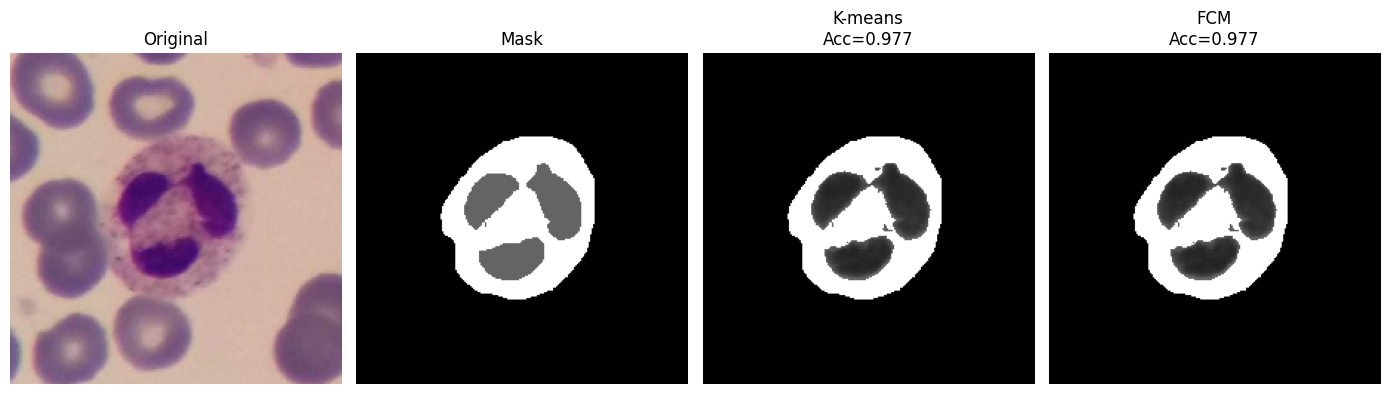

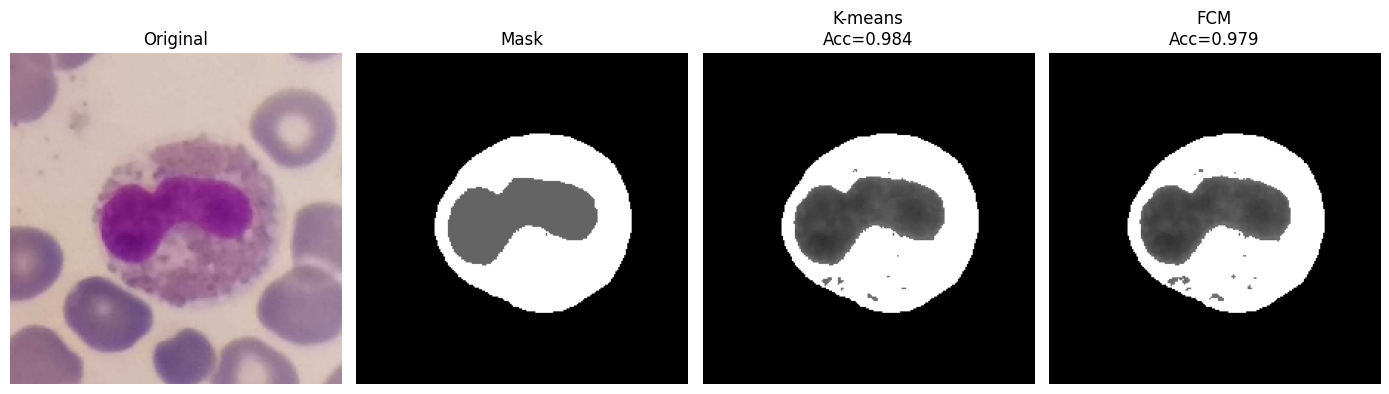

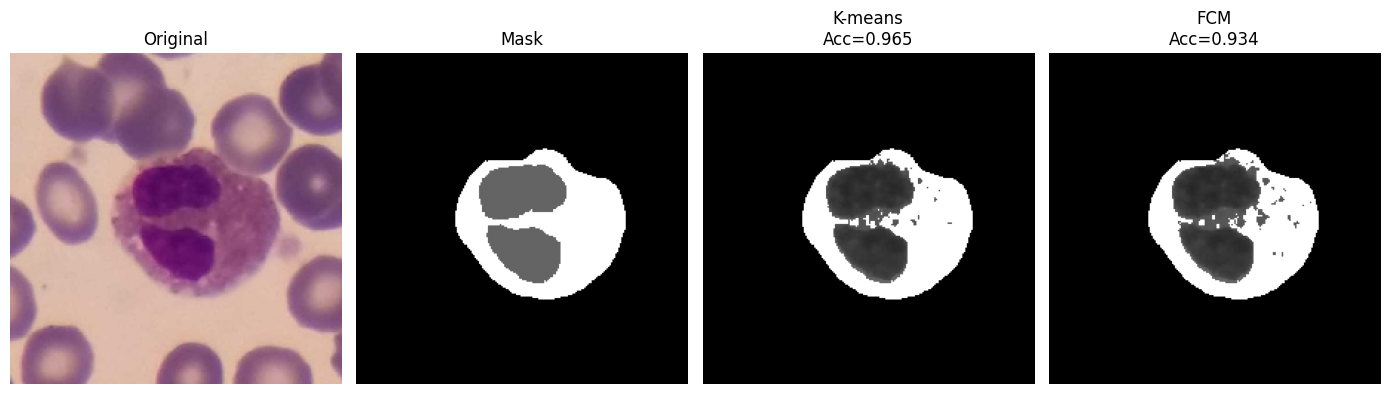

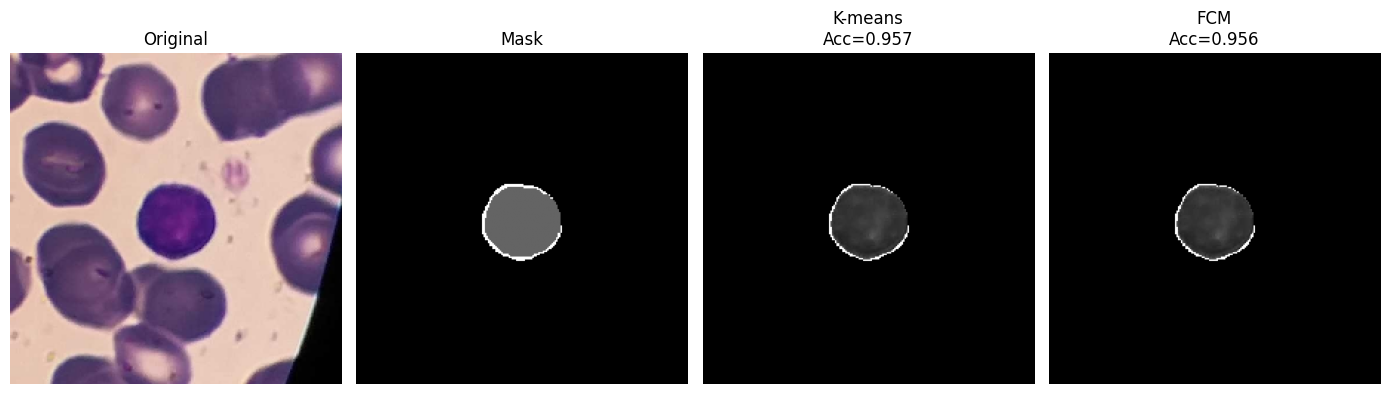

Mean Accuracy  K-means: 0.9705  |  FCM: 0.9614


In [35]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

def kmeans(img, mask, iters=10):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    mask_bin = mask > 0
    pixels = img_gray[mask_bin]
    c1 = pixels[np.random.randint(len(pixels))]
    c2 = pixels[np.random.randint(len(pixels))]
    for _ in range(iters):
        d1 = np.abs(pixels - c1)
        d2 = np.abs(pixels - c2)
        cluster1 = d1 <= d2
        c1_new = pixels[cluster1].mean() if np.any(cluster1) else c1
        c2_new = pixels[~cluster1].mean() if np.any(~cluster1) else c2
        if np.abs(c1_new - c1) < 1e-2 and np.abs(c2_new - c2) < 1e-2:
            break
        c1, c2 = c1_new, c2_new
    d1 = np.abs(pixels - c1)
    d2 = np.abs(pixels - c2)
    labels = (d1 <= d2).astype(np.uint8)
    if c1 > c2:
        labels = 1 - labels
    result = np.zeros(img_gray.shape, dtype=np.uint8)
    result[mask_bin] = labels * 255
    return result

def fcm(img, mask, iters=10, m=2):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).astype(np.float32)
    mask_bin = mask > 0
    pixels = img_gray[mask_bin]
    u1 = np.random.rand(len(pixels))
    u2 = 1 - u1
    c1, c2 = 0, 0
    for _ in range(iters):
        c1 = np.sum((u1**m) * pixels) / (np.sum(u1**m) + 1e-6)
        c2 = np.sum((u2**m) * pixels) / (np.sum(u2**m) + 1e-6)
        d1 = np.abs(pixels - c1) + 1e-6
        d2 = np.abs(pixels - c2) + 1e-6
        u1 = 1 / (1 + (d1 / d2) ** (2 / (m - 1)))
        u2 = 1 - u1
    labels = (u1 > u2).astype(np.uint8)
    if c1 > c2:
        labels = 1 - labels
    result = np.zeros(img_gray.shape, dtype=np.uint8)
    result[mask_bin] = labels * 255
    return result

def overlay_nucleus_on_mask(img, mask, nucleus_seg):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    result = mask.copy()
    result[nucleus_seg > 0] = img_gray[nucleus_seg > 0]
    return result

def accuracy(overlay, mask):
    nonblack = mask != 0

    pred_nucleus = overlay[nonblack] < 255   # gray = nucleus
    gt_nucleus   = mask[nonblack]   < 255    # non-white inside mask = nucleus

    tp    = np.sum(pred_nucleus == gt_nucleus)
    total = np.sum(nonblack)
    return tp / total if total > 0 else 0.0

img_dir  = '/kaggle/input/datasets/ntxmaihd/raabin-wbc-segmentation/Train_bmp'
mask_dir = '/kaggle/input/datasets/ntxmaihd/raabin-wbc-segmentation/Train_GT_bmp'

accs_k, accs_fcm = [], []

for fname in os.listdir(img_dir)[2:6]:
    img_path  = os.path.join(img_dir, fname)
    mask_path = os.path.join(mask_dir, fname)

    img  = cv2.imread(img_path)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    if img is None or mask is None:
        print(f"{fname}: not found")
        continue

    img  = cv2.resize(img,  (224, 224), interpolation=cv2.INTER_NEAREST)
    mask = cv2.resize(mask, (224, 224), interpolation=cv2.INTER_NEAREST)

    k_seg   = kmeans(img, mask)
    fcm_seg = fcm(img, mask)

    k_result   = overlay_nucleus_on_mask(img, mask, k_seg)
    fcm_result = overlay_nucleus_on_mask(img, mask, fcm_seg)

    ak = accuracy(k_result,   mask)
    af = accuracy(fcm_result, mask)

    accs_k.append(ak)
    accs_fcm.append(af)

    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    axes[0].imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original')
    axes[1].imshow(mask,       cmap='gray')
    axes[1].set_title('Mask')
    axes[2].imshow(k_result,   cmap='gray')
    axes[2].set_title(f'K-means\nAcc={ak:.3f}')
    axes[3].imshow(fcm_result, cmap='gray')
    axes[3].set_title(f'FCM\nAcc={af:.3f}')
    for ax in axes: ax.axis('off')
    plt.tight_layout()
    plt.show()

print(f"Mean Accuracy  K-means: {np.mean(accs_k):.4f}  |  FCM: {np.mean(accs_fcm):.4f}")